<a href="https://colab.research.google.com/github/TomerRippin/Machine-Learning/blob/master/Machine_learning_softmax_regression_gradient_descent_methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Maman12 - introduction to machine learning ###
Student: Tomer Rippin
I.D: 322230608

In [1]:
# Import all of the libraris
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random

from tensorflow.keras.datasets import fashion_mnist
from tqdm.notebook import tqdm, trange

### Loading the data ###
Our data consists of 28x28 pixel grayscale images of various clothing items, each
belonging to one of ten categories: T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt,
Sneaker, Bag, and Ankle boot.

In [2]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Dataset Details ###


*   Each image is 28 pixels in height and 28 pixels in width, resulting in a total of 784
pixels per image
*   Each image is 28 pixels in height and 28 pixels in width, resulting in a total of 784
pixels per image

*   Each image represents one of ten clothing categories, with natural variations in
shape, texture, and visual appearance between items
*   Each sample is assigned a label (0 to 9), corresponding to one of ten clothing
categories.


In [3]:
# A dictionary for the translation of the numeral catagories
# to their matching names.
label2catagory = {
    0: "T-shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

### Data Preprocessing ###
#### **Reshaping**: ####
  We want to reshape the images from 28x28 pixel to a 784x1 vector.
#### **Normalization**: ####
  In this experiment we use the min-max noramalization method.
  The formula for this normalization is:


$\frac{(value - min)}{(max - min)}$

because our min is 0 we can just divide the vectors by 255 to normalize equaly between 0 and 1.


#### **Bias**: ####
  We add a 1 to the start of the vector for the bias so now the shape of every vector is 785x1.

In [4]:
def preprocess_images(data):
  encoded_data = []
  for image in tqdm(data):
    image = image.reshape(784,)
    image = image / 255  # Normalization
    image = np.insert(image, 0, 1)  # Add the Bias as the first element
    encoded_data.append(image)
  return encoded_data

print("Preprocess train images")
X_train = np.array(preprocess_images(X_train))

print("Preprocess test images")
X_test = np.array(preprocess_images(X_test))

Preprocess train images


  0%|          | 0/60000 [00:00<?, ?it/s]

Preprocess test images


  0%|          | 0/10000 [00:00<?, ?it/s]

#### One-Hot encoding ####
we now apply a one-hot encoding for our labels.
instead of 0-9 we will use a 10x1 vector.
we will denote 1 as the "True" label and -1 as the "False" label.
For example:

$ 4 \rightarrow [-1, -1, -1, 1, -1, -1, -1, -1, -1, -1]$


In [5]:
# One-hot encode the labels, from 0-9 labels to a 10-dmensional vector
def one_hot_encode(data):
  encoded_data = []
  for row in tqdm(data):
    one_hot_vector = np.array([0] * 10)  # initialize a 10x1 vector with 0
    one_hot_vector[row] = 1  # switch the correct label with 1
    encoded_data.append(one_hot_vector)
  return encoded_data

print("Encoding test vectors")
y_test = np.array(one_hot_encode(y_test))


print("Encoding train vectors")
y_train = np.array(one_hot_encode(y_train))

Encoding test vectors


  0%|          | 0/10000 [00:00<?, ?it/s]

Encoding train vectors


  0%|          | 0/60000 [00:00<?, ?it/s]

### Calculating the Gradient of Eᵢₙ(w) ###
For gradient-decent optmization we first need to calculate the gradient to our target function $E_{in}$.


we denote the softmax function as $P_{nk}$:
$$
P_{nk} = \frac{e^{w_k^T x_n}}{\sum_{i} e^{w_i^T x_n}}\
$$
such that $E_{in}$ simplfied will be:
$$
E_{in}(w) = - \sum_{n=1}^{N} \sum_{k=1}^{K} \mathbb{1}\{y_n = k\} \ln(P_{nk})
$$

Since the derivative of a sum is the sum of derivatives, we can focus on the derivative for a single sample $n$ and then sum them up at the end. Let's look at the loss for just one data point, $L_n$:
$$
L_n(w) = - \sum_{k=1}^{K} \mathbb{1}\{y_n = k\} \ln(P_{nk})
$$

Using the derivative of log, $\frac{\partial}{\partial x} \ln(f(x)) = \frac{1}{f(x)} f'(x)$, we get:
$$
\frac{\partial L_n}{\partial {w}_j} = - \sum_{k=1}^{K} \mathbb{1}\{y_n = k\} \frac{1}{P_{nk}} \frac{\partial P_{nk}}{\partial{w}_j}
$$



To make the math cleaner, I will define the $z_k = w_k^T x_n$.
Put it $P_{nk}$:
$$
P_{nk} = \frac{e^{z_k}}{\sum_{i=1}^{K} e^{z_i}}
$$

We are differentiating with respect to ${w}_j$. By the Chain Rule, I will first differentiate with respect to the score $z_j$, and then multiply by $\frac{\partial z_j}{\partial{w}_j}$ (which is simply ${x}_n$).

So let's focus on $\frac{\partial P_{nk}}{\partial z_j}$. This requires the Quotient Rule:$$\left( \frac{u}{v} \right)' = \frac{u'v - uv'}{v^2}$$Here, $u = e^{z_k}$ and $v = \sum_{i=1}^{K} e^{z_i}$.

There are two distinct scenarios depending on whether $k = j$:





#### $k=j$ ####

Numerator ($u = e^{z_j}$): The derivative with respect to $z_j$ is $e^{z_j}$.

Denominator ($v = \sum e^{z_i}$): The derivative with respect to $z_j$ is $e^{z_j}$ (since only one term in the sum contains $z_j$).

Applying the Quotient Rule:


$$
\begin{aligned}
\frac{\partial P_{nj}}{\partial z_j} &= \frac{(e^{z_j})(\sum e^{z_i}) - (e^{z_j})(e^{z_j})}{(\sum e^{z_i})^2} \\
&= \frac{e^{z_j}}{\sum e^{z_i}} \cdot \frac{\sum e^{z_i} - e^{z_j}}{\sum e^{z_i}} \\
&= P_{nj} (1 - P_{nj})
\end{aligned}
$$


Finally, multiplying by ${x}_n$ (from the chain rule on $w_j^T x_n$) we get (1):
$$
\frac{\partial P_{nj}}{\partial {w}_j} = P_{nj}(1 - P_{nj}) {x}_n
$$

#### $k \neq j$ ####

Numerator ($u = e^{z_k}$):

The derivative with respect to $z_j$ is $0$ (since $z_k$ does not depend on $z_j$).

Denominator ($v = \sum e^{z_i}$): The derivative with respect to $z_j$ is still $e^{z_j}$.

Applying the Quotient Rule:
$$
\begin{aligned}
\frac{\partial P_{nk}}{\partial z_j} &= \frac{(0)(\sum e^{z_i}) - (e^{z_k})(e^{z_j})}{(\sum e^{z_i})^2} \\
&= - \frac{e^{z_k} e^{z_j}}{(\sum e^{z_i})^2} \\
&= - \frac{e^{z_k}}{\sum e^{z_i}} \cdot \frac{e^{z_j}}{\sum e^{z_i}} \\
&= - P_{nk} P_{nj}
\end{aligned}
$$

Multiplying by ${x}_n$ we get (2):
$$
\frac{\partial P_{nk}}{\partial{w}_j} = - P_{nk} P_{nj}{x}_n
$$

We need to split this summation into two parts: the single term where $k=j$ and all the other terms where $k \neq j$.
$$
\frac{\partial L_n}{\partial {w}_j} = - \left[ \underbrace{\mathbb{1}\{y_n = j\} \frac{1}{P_{nj}} \frac{\partial P_{nj}}{\partial {w}_j}}_{\text{Case } k=j} + \sum_{k \neq j} \underbrace{\mathbb{1}\{y_n = k\} \frac{1}{P_{nk}} \frac{\partial P_{nk}}{\partial {w}_j}}_{\text{Case } k \neq j} \right]
$$

Subsitute (1) and (2):

$$
\frac{\partial L_n}{\partial {w}_j} = - \left[ \mathbb{1}\{y_n = j\} \frac{1}{P_{nj}} \left( P_{nj}(1 - P_{nj}){x}_n \right) + \sum_{k \neq j} \mathbb{1}\{y_n = k\} \frac{1}{P_{nk}} \left( -P_{nk} P_{nj} {x}_n \right) \right]
$$

Cancel the probabilities:
$$
\frac{\partial L_n}{\partial {w}_j} = - \left[ \mathbb{1}\{y_n = j\} (1 - P_{nj}){x}_n - \sum_{k \neq j} \mathbb{1}\{y_n = k\} P_{nj} {x}_n \right]
$$

Expand the Terms:
$$
\frac{\partial L_n}{\partial {w}_j} = {- \mathbb{1}\{y_n = j\} {x}_n + \mathbb{1}\{y_n = j\} P_{nj} {x}_n} + {\sum_{k \neq j} \mathbb{1}\{y_n = k\} P_{nj}{x}_n}
$$

Factor $P_{nj} x_n$:
$$
\frac{\partial L_n}{\partial{w}_j} = - \mathbb{1}\{y_n = j\} {x}_n + P_{nj} {x}_n \left( \mathbb{1}\{y_n = j\} + \sum_{k \neq j} \mathbb{1}\{y_n = k\} \right)
$$

Note the Right part of the equation:

This is simply the sum of the indicator function over all possible classes $k$.

Since the true label $y_n$ must belong to exactly one class, one of these indicators will be 1 and the rest will be 0.
Therefore, the sum inside the parentheses is exactly 1.

Replacing the parentheses with 1, we get:
$$
\frac{\partial L_n}{\partial {w}_j} = - \mathbb{1}\{y_n = j\} {x}_n + P_{nj} {x}_n
$$
Inserting $P_{nj}$ to recieve:
$$
\frac{\partial L_n}{\partial{w}_j} = (P_{nj} - \mathbb{1}\{y_n = j\}){x}_n
$$

Summing over all samples gives you the final formula:
$$
\nabla_{{w}_j} E_{in} = \sum_{n=1}^{N} (P_{nj} - \mathbb{1}\{y_n = j\}) {x}_n
$$

This derivation proves that despite the complex log and exponential functions, the gradient is simply (Prediction - Truth) $\times$ Input.

#### Sofmax Matrix Calculation ####
In this part of the code we will calculate the Softmax matrix P.

First, we calculate the raw scores for every class for every sample using a matrix product.$$Z = XW$$$Z$ will have the shape $(N, K)$. Each entry $z_{nk}$ is the score for sample $n$ and class $k$.

Then Apply the softmax formula across each row:
$$
P_{nk} = \frac{e^{z_{nk}}}{\sum_{j=1}^{K} e^{z_{nj}}}
$$

In [6]:
def softmax(X, W):
  """
  shapes:
  X.shape = (N, d)
  W.shape = (d, k)

  P.shape = (N, k)
  """

  Z = X @ W

  # Subtract the maximum value from each row.
  # This prevents "Overflow" errors where e^z becomes too large.
  Z_shifted = Z - np.max(Z, axis=1, keepdims=True)
  e_z = np.exp(Z_shifted)

  P = e_z / np.sum(e_z, axis=1, keepdims=True)

  return P

### Final gradient calculation ###
Lets write the gradient formula using fast matrix multiplication.

we have X in shape (N, d)

one hot encoded Y in shape (N, K)

softmax probability matrix P (N, K)

in our case the number of classes K is 10.



```
gradient = X.T @ (P - Y)
```



In [7]:
def gradient(X, W, Y):
  """
  X.shape = (N, d)
  W.shape = (d, k)
  Y.shape = (N, k)
  """
  N, d = X.shape
  P = softmax(X, W)
  error = P - Y
  return (X.T @ error) / N

### $W_0$ initalization ###
we are choosing $w_0 \neq 0$ because If you set every weight in your $(d, k)$ matrix to exactly zero, every single class will receive the exact same input signal.

1. Identical Predictions: For any input $x$, the initial $Z = XW$ will be a vector of zeros.

2. Softmax Output: The softmax of a zero-vector is a uniform distribution (e.g., $0.1$ for each of the 10 classes).

3. Identical Gradients: Because the error $(P - Y)$ is distributed identically across the weights for each class, the gradients for every column in $W$ will be the same.

When all weights update by the exact same amount, they stay identical to each other throughout the training process. The model effectively collapses into a single-class predictor.

In [8]:
w0 = np.random.randn(785, 10) * 0.01

# Gradient Descent Algorhithm Choice #
In class we looked at couple of Gradient Descent algorithms: Batch, Variable Learning Rate ('Bold Driver') and Stochastic.

Well check both of them on the data and choose the best one.

#### Batch Gradient Descent ####
Batch Gradient Descent computes the gradient of the cost function using the entire training dataset for each iteration. This approach ensures that the computed gradient is precise, but it can be computationally expensive when dealing with very large datasets.


1. Initialize $w(t) = w_0$
2. for t = 0,1,2 to max_epochs do:
3. compute the gradient $g_t = \nabla E_{in}(w(t))$
4. set the direction $ v_t = -g_t$
5. update the weights $w(t+1) = w(t) + \eta g_t$

In [9]:
def batch_gradient_descent(X, Y, w0, lr=0.01, max_epochs=1000, tolerance=1e-5):
  w = w0.copy()
  history = []
  for t in trange(max_epochs):
    v = -1 * gradient(X, w, Y)
    w = w + lr * v

    history.append((t,w,v))

  return w, history

In [10]:
print("Learning batch gradient descent")
w_hat_batch, bgd_history = batch_gradient_descent(X_train, y_train, w0, lr=0.01, max_epochs=500)


Learning batch gradient descent


  0%|          | 0/500 [00:00<?, ?it/s]

##### **BGD Results Analsys** #####
first, we will plot the cross entropy loss and the gradient norm to see if we can see a convergence.

I chose max_epochs=500 and lr=0.01 after i tried some runs and saw i have good convergence after this number of epochs and good results. giving the model more epochs may have given us a little bit better score but will cost us more computation which I decided against.

In [11]:
def plot_training_results(X, Y, weights_history):
    epochs = [item[0] for item in weights_history]
    weights = [item[1] for item in weights_history]
    grads = [item[2] for item in weights_history]

    losses = []
    grad_norms = []
    weight_magnitudes = []

    # Extract data from history
    for w, g in tqdm(zip(weights, grads), desc="loss calculation"):
        # 1. Calculate Loss for this weight set
        P = softmax(X, w)
        loss = -np.mean(np.sum(Y * np.log(P + 1e-9), axis=1))
        losses.append(loss)

        # 2. Calculate Gradient Norm
        grad_norms.append(np.linalg.norm(g))


    # Create the Plots
    fig, ax = plt.subplots(1, 2, figsize=(18, 5))

    # Plot 1: Loss
    ax[0].plot(epochs, losses, color='blue', lw=2)
    ax[0].set_title("Cross-Entropy Loss")
    ax[0].set_xlabel("Epoch")
    ax[0].grid(True)

    # Plot 2: Gradient Norm
    ax[1].plot(epochs, grad_norms, color='red', lw=2)
    ax[1].set_title("Gradient Norm (v)")
    ax[1].set_xlabel("Epoch")
    ax[1].grid(True)

    plt.tight_layout()
    plt.show()


loss calculation: 0it [00:00, ?it/s]

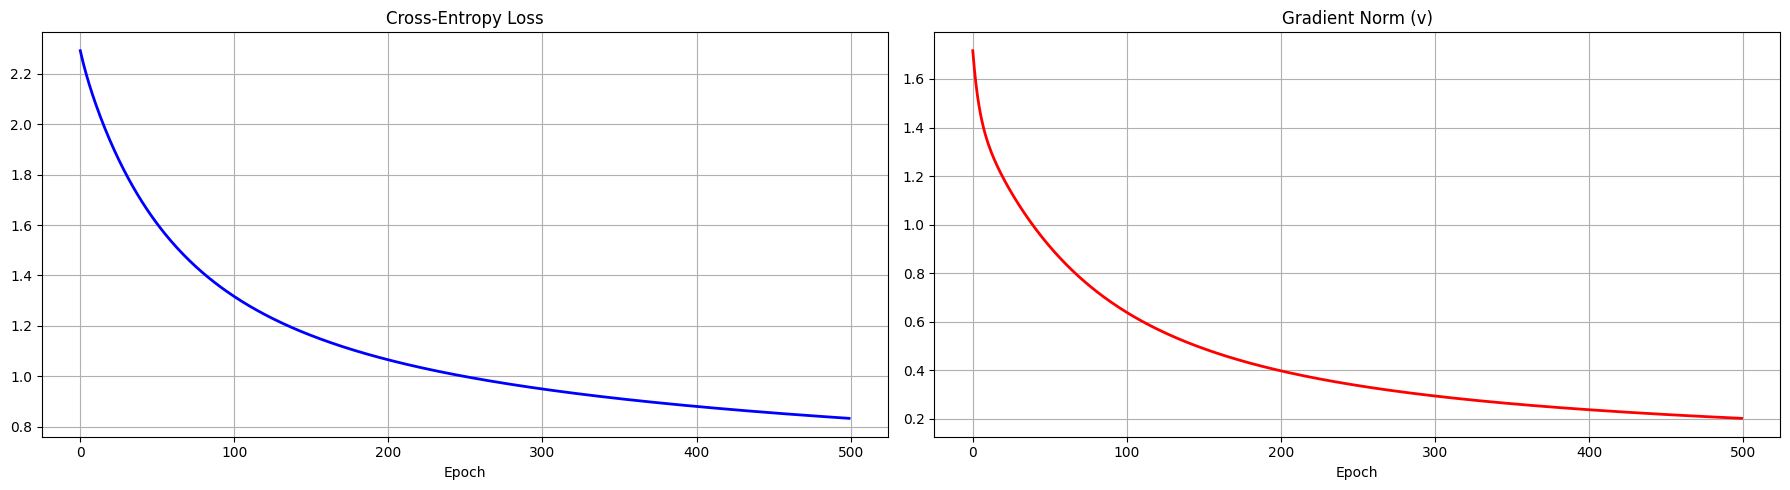

In [12]:
plot_training_results(X_train, y_train, bgd_history)

##### **Weights visualization** #####
I had good convergence after 500 epochs but i wanted to also check if like my PLA algorithm I can visualize the weights of $\hat w$ and see the classes as a heatmap.

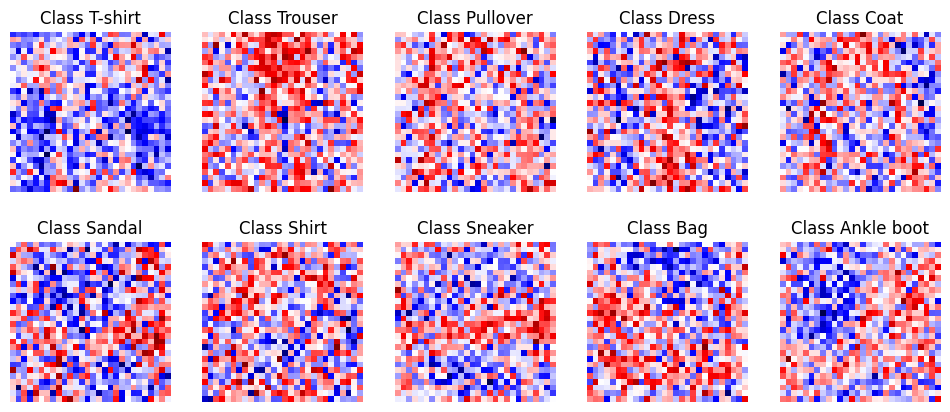

In [201]:
def visualize_weights(w):
    weights_no_bias = w[1::, :]

    plt.figure(figsize=(12, 5))
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        # Reshape the 784 weights back into a 28x28 image
        plt.imshow(weights_no_bias[:, i].reshape(28, 28), cmap='seismic')
        plt.title(f"Class {label2catagory[i]}")
        plt.axis('off')
    plt.show()

visualize_weights(w_hat_batch)

It looks **pretty bad...**

almost all of the classes are noise and nothing close to the nice visualization we had at the PLA algorithm. we can see some similiarities to the actual class in T-shirt and sneaker but not as good as before.

for that reason, we will try and look at a more sophisticated gradient decsent algorithm.

In [13]:
def get_accuracy(X, Y, W):
    """
    Calculates accuracy for a given weight matrix W.
    """
    P = softmax(X, W)
    predictions = np.argmax(P, axis=1)
    labels = np.argmax(Y, axis=1)
    return np.mean(predictions == labels)

In [14]:
print(f"Final Accuarcy: {get_accuracy(X_test, y_test, w_hat_batch)}")

Final Accuarcy: 0.7271


##### **Train vs Test Accuarcy** #####
Now, we will show the train vs test accuarcy graph to see the learning process over time.

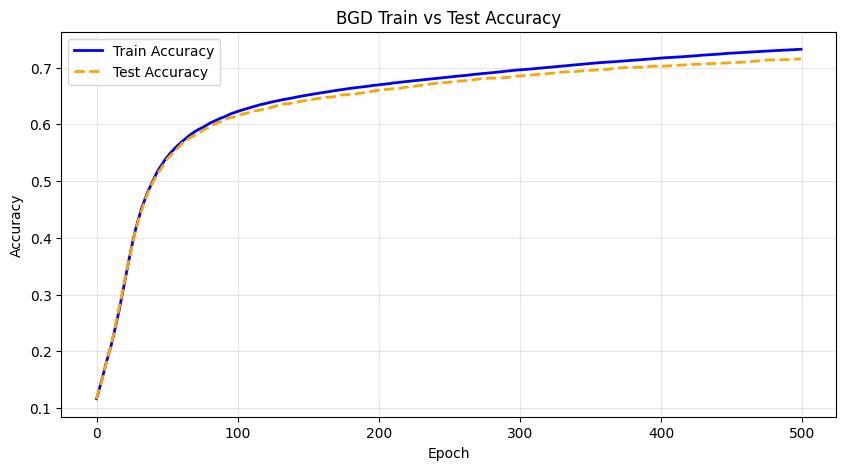

In [224]:
bgd_train_acc = []
bgd_test_acc = []

for epoch, w_curr, grad in tqdm(bgd_history):
    bgd_train_acc.append(get_accuracy(X_train, y_train, w_curr))
    bgd_test_acc.append(get_accuracy(X_test, y_test, w_curr))

def plot_accuracies(train_acc, test_acc, title="Accuracy over Epochs"):
    plt.figure(figsize=(10, 5))
    plt.plot(train_acc, label='Train Accuracy', color='blue', linewidth=2)
    plt.plot(test_acc, label='Test Accuracy', color='orange', linestyle='--', linewidth=2)
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_accuracies(bgd_train_acc, bgd_test_acc, "BGD Train vs Test Accuracy")

We can see that the train ans test Accuarcies are pretty similar and converge at about 0.72.
This result is not as good as we got in the PLA algorithm (When we got 0.77) so we will try and improve with a different version of Gradient Decsent algorithm.

####Variable Learning Rate Gradient Descent ####
We saw in class this new approach to the batch gradient decsent problem.

In this algorithm we adapt the learning rate to the error.

If the error drops, increase η;

If not, the step was too large, so reject the update and decrease η;

For little extra effort, we get a significant boost to gradient descent.

1. Initialize $w(t) = w_0$, set $ \alpha > 1$ and  $\beta < 1$
2. while stopping criteria has not been met:
3. compute the gradient $g_t = \nabla E_{in}(w(t))$
4. set the direction $ v_t = -g_t$
5. if $E_{in} (w(t) + \eta v(t)) < E_{in}(w(t))$
6. accept: $w(t+1) = w(t) + \eta v(t)$; $n_{t+1} = \alpha \eta_{t}$  
7. else
8. reject: $w(t+1) = w(t)$; $n_{t+1} = \beta \eta_t$

In [15]:
def variable_learning_rate_gradient_descent(X, Y, w0, alpha, beta,lr=0.01, max_epochs=100):
    w = w0.copy()
    N, d = X.shape
    P = softmax(X, w)

    # we add small value to P such that if P=0 our program will not crash as log(p) -> infinity
    ein = -np.sum(Y * np.log(P + 1e-9)) / N

    # Trackers for analysis
    weight_history = [w.copy()]
    lr_history = []

    t = trange(max_epochs, desc="VLR-GD Training")

    for epoch in t:
        v = -1 * gradient(X, w, Y)
        w_new = w + lr * v

        P_new = softmax(X, w_new)
        ein_new = -np.sum(Y * np.log(P_new + 1e-9)) / N

        if ein_new < ein:
            # Step accepted: Update weights and increase LR
            w = w_new
            ein = ein_new
            lr *= alpha
            status = "Up"
        else:
            # Step rejected: Keep old weights and shrink LR
            lr *= beta
            status = "Down"

        # Snapshot current state
        weight_history.append(w.copy())
        lr_history.append(lr)

        t.set_postfix({'Loss': f'{ein:.4f}', 'LR': f'{lr:.6f}', 'Step': status})

    return w, weight_history, lr_history

##### Parameters selection #####
I chose $\alpha = 1.05$ and $\beta = 0.7$ after some tries and saw these gave the best results with the fastest convergence rate.

In [16]:
print("Learning variable learning rate gradient descent")
w_hat_vlr, weight_history, lr_history = variable_learning_rate_gradient_descent(X_train, y_train, w0, alpha=1.05, beta=0.7)

Learning variable learning rate gradient descent


VLR-GD Training:   0%|          | 0/100 [00:00<?, ?it/s]

With the next function we will translate the weight history and lr history to a nice format that will be easier to plot.

will also plot the accuarcy of the test and the training over time in a way we can compare to the BGD result.

In [18]:
def compute_vlr_history(weight_history, lr_history, X_train, Y_train, X_test, Y_test):
    history = []
    N_train = X_train.shape[0]

    # Analyze each epoch's weight snapshot
    for t in tqdm(range(len(lr_history)), desc="Analyzing vlr data"):
        w_curr = weight_history[t+1]

        # 1. Train Metrics
        P_train = softmax(X_train, w_curr)
        train_loss = -np.mean(np.sum(Y_train * np.log(P_train + 1e-12), axis=1))
        train_acc = np.mean(np.argmax(P_train, axis=1) == np.argmax(Y_train, axis=1))

        # 2. Test Metrics
        P_test = softmax(X_test, w_curr)
        test_acc = np.mean(np.argmax(P_test, axis=1) == np.argmax(Y_test, axis=1))

        # Package: (epoch, loss, lr, train_acc, test_acc)
        history.append((t, train_loss, lr_history[t], train_acc, test_acc))

    return history
vlr_history = compute_vlr_history(weight_history, lr_history, X_train, y_train, X_test, y_test)

Analyzing vlr data:   0%|          | 0/100 [00:00<?, ?it/s]

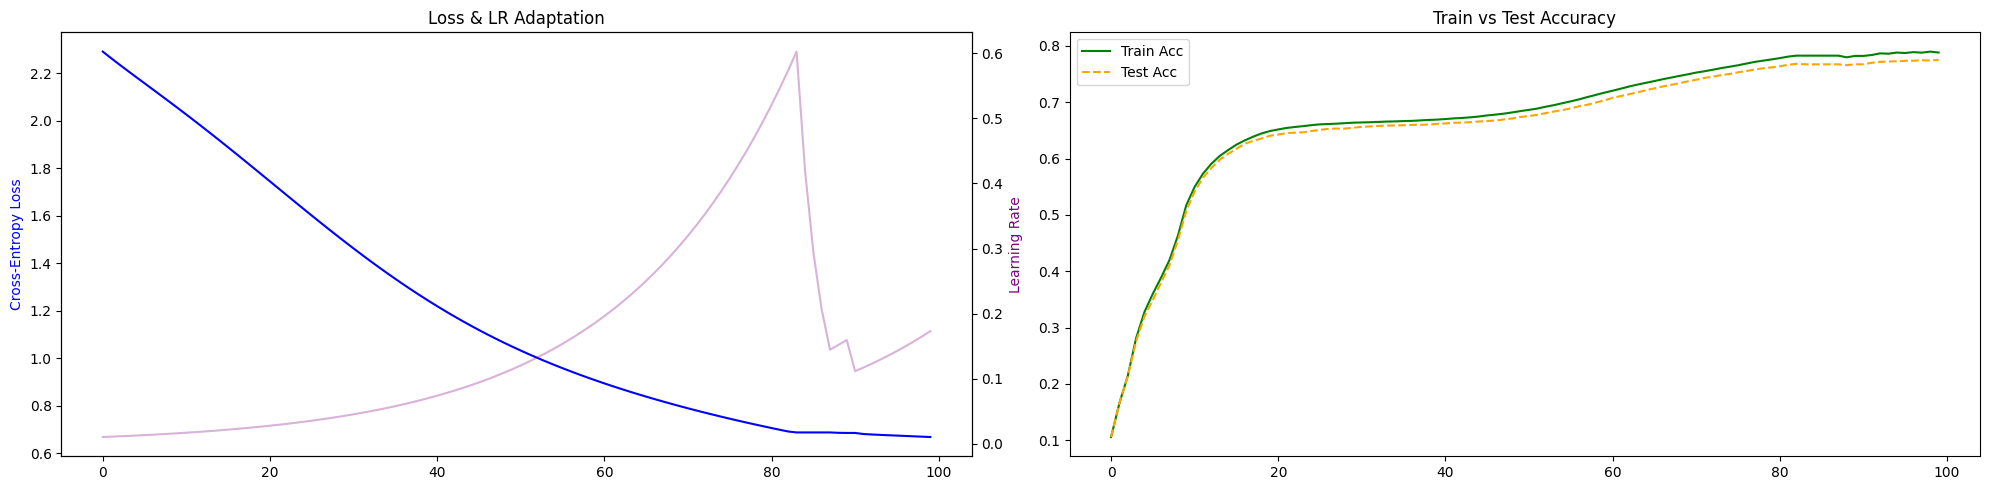

In [19]:
def plot_vlr_analysis(history):
    epochs = [h[0] for h in history]
    losses = [h[1] for h in history]
    lrs    = [h[2] for h in history]
    t_acc  = [h[3] for h in history]
    v_acc  = [h[4] for h in history]

    fig, ax = plt.subplots(1, 2, figsize=(20, 5))

    # Panel 1: Loss & Learning Rate (Dual Axis)
    ax[0].plot(epochs, losses, color='blue', label='Loss')
    ax[0].set_ylabel("Cross-Entropy Loss", color='blue')
    ax[0].set_title("Loss & LR Adaptation")

    ax0_twin = ax[0].twinx()
    ax0_twin.plot(epochs, lrs, color='purple', alpha=0.3, label='LR')
    ax0_twin.set_ylabel("Learning Rate", color='purple')


    # Panel 2: Accuracy
    ax[1].plot(epochs, t_acc, color='green', label='Train Acc')
    ax[1].plot(epochs, v_acc, color='orange', linestyle='--', label='Test Acc')
    ax[1].set_title("Train vs Test Accuracy")
    ax[1].legend()

    plt.tight_layout()
    plt.show()
plot_vlr_analysis(vlr_history)

In [20]:
print(f"Final VLR-GD Accuarcy: {get_accuracy(X_test, y_test, w_hat_vlr)}")

Final VLR-GD Accuarcy: 0.7755


#### **VLR graph Analsys** ####
In the first panel we can see that the lr was going up as the loss dropped but just at epoch 82 we can see a stop in the loss that caused a major 'break' in the lr which then settled as the model converged and the loss stopped changhing.

In the second panel we can see that we got much better accuarcy from the BGD algorithm as we got almost 0.78 accuarcy!

In our Pure Accuarcy is looking close to the PLA algorithm Accuarcy, but can we do any better?

Lets check out how the weights look.

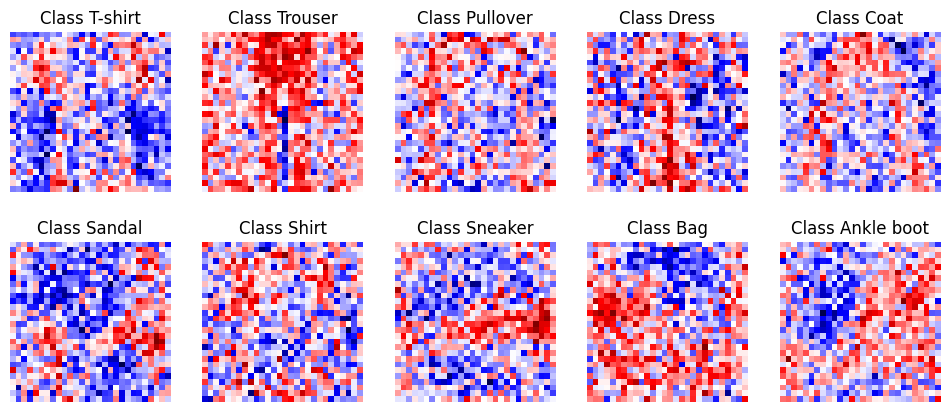

In [249]:
visualize_weights(w_hat_vlr)

The heatmap looks just a little better than BGD

We **still** cannot differentiate the classes with just looking at them but there is a clear improvment.

After the Success in the VLR stratagy we will try and see if SGD can be even better as the aproach is really different.

#### Stochastic Gradient Descent ####
Stochastic Gradient Descent (SGD) addresses the inefficiencies of Batch Gradient Descent by computing the gradient using only a single training example (or a small subset) in each iteration. This makes the algorithm much faster since only a small fraction of the data is processed at each step.


In this algorithm we will pick a training data at random. Then calculate only the error on that data point.

the gradient on this signle data points error is used for the weight update:

$ w{(t+1)} = w{(t)} - \eta \nabla E_{in}{(t)} (x_n)$

In [22]:
def stochastic_gradient_descent(X, Y, w0, lr=0.01, max_epochs=50):
    w = w0.copy()
    N, d = X.shape

    # Store weights and grad norms for analysis
    weight_history = [w.copy()]
    avg_grads_per_epoch = []

    for epoch in trange(max_epochs, desc="SGD Training"):
        random_index = np.random.permutation(N)
        step_grads = []

        for i in random_index:
            xi = X[i:i+1]
            yi = Y[i:i+1]

            grad = gradient(xi, w, yi)
            w -= lr * grad
            step_grads.append(np.linalg.norm(grad))

        weight_history.append(w.copy())
        avg_grads_per_epoch.append(np.mean(step_grads))

    return w, weight_history, avg_grads_per_epoch

#####Parameters selection #####
I chose a smaller lr in the SGD as a 0.01 lr didnt seem to get good results for me. i think that because we have so many updates using the lr in one epoch that a smaller lr with a small weight for each update is much healther to the model.

In [23]:
w_hat_sgd, weights, grads = stochastic_gradient_descent(X_train, y_train, w0, lr=0.001)

SGD Training:   0%|          | 0/50 [00:00<?, ?it/s]

We will now transfer the weights and gradients to a nicer format that will allow us to plt it with ease.

In [27]:
def compute_sgd_history(weight_history, avg_grads, X_train, Y_train, X_test, Y_test):
    """
    Returns: list of tuples (epoch, loss, avg_grad_norm, train_acc, test_acc)
    """
    history = []
    N_train = X_train.shape[0]

    # weight_history[0] is initial w0, snapshots start at index 1
    for t in tqdm(range(len(avg_grads)), desc="Analyzing SGD Epochs"):
        w_curr = weight_history[t+1]

        # 1. Global Loss
        P_train = softmax(X_train, w_curr)
        loss = -np.mean(np.sum(Y_train * np.log(P_train + 1e-9), axis=1))

        # 2. Train Accuracy
        train_preds = np.argmax(P_train, axis=1)
        train_acc = np.mean(train_preds == np.argmax(Y_train, axis=1))

        # 3. Test Accuracy
        P_test = softmax(X_test, w_curr)
        test_preds = np.argmax(P_test, axis=1)
        test_acc = np.mean(test_preds == np.argmax(Y_test, axis=1))

        # Package for the plot: (epoch, loss, grad_norm, train_acc, test_acc)
        history.append((t, loss, avg_grads[t], train_acc, test_acc))

    return history
sgd_history = compute_sgd_history(weights, grads, X_train, y_train, X_test, y_test)

Analyzing SGD Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

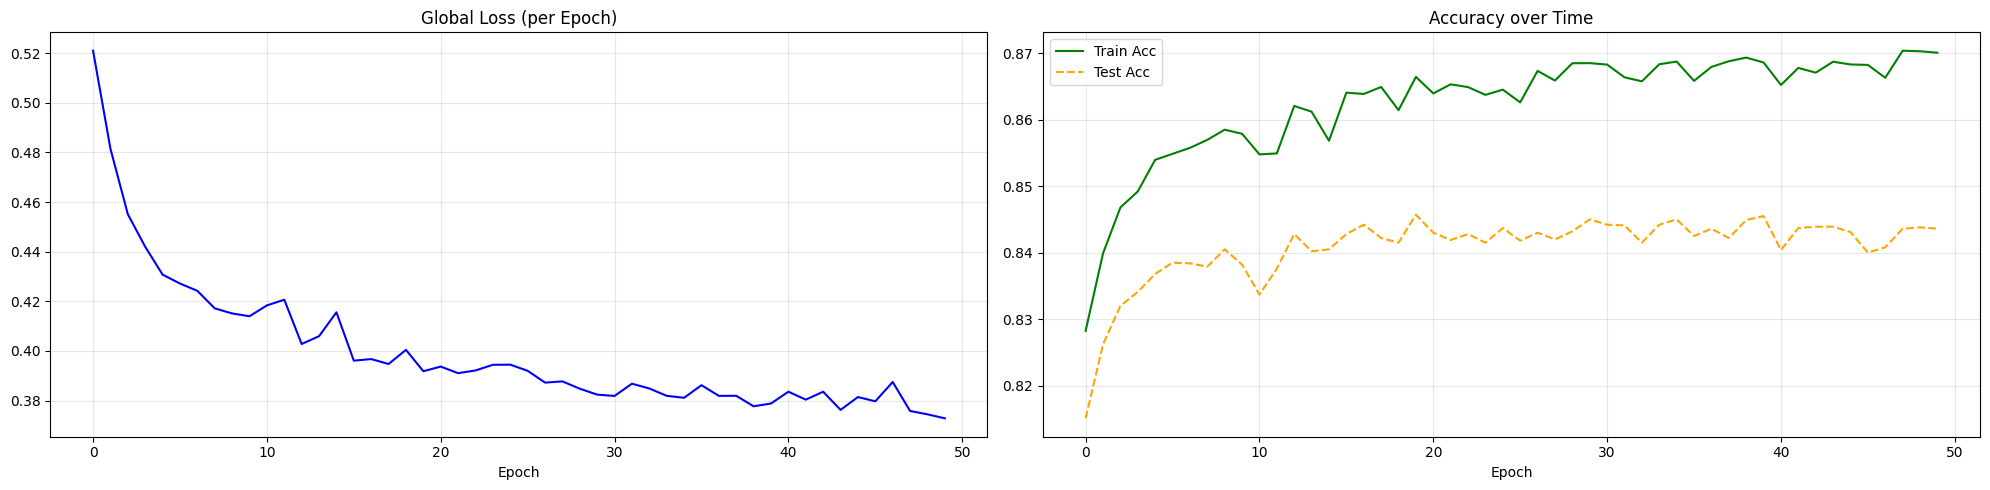

In [25]:
def plot_sgd_analysis(history):
    epochs = [h[0] for h in history]
    losses = [h[1] for h in history]
    grads  = [h[2] for h in history]
    t_acc  = [h[3] for h in history]
    v_acc  = [h[4] for h in history]

    fig, ax = plt.subplots(1, 2, figsize=(20, 5))

    # Panel 1: Loss
    ax[0].plot(epochs, losses, color='blue', label='Train Loss')
    ax[0].set_title("Global Loss (per Epoch)")
    ax[0].set_xlabel("Epoch")
    ax[0].grid(True, alpha=0.3)

    # Panel 2: Accuracy (Train vs Test)
    ax[1].plot(epochs, t_acc, color='green', label='Train Acc')
    ax[1].plot(epochs, v_acc, color='orange', linestyle='--', label='Test Acc')
    ax[1].set_title("Accuracy over Time")
    ax[1].set_xlabel("Epoch")
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_sgd_analysis(sgd_history)

In [26]:
print(f"Final SGD Accuarcy: {get_accuracy(X_test, y_test, w_hat_sgd)}")

Final SGD Accuarcy: 0.8436


#### **SGD graphs visualization**
Right from the start we can see that we achieved much better loss and much higher accuarcy just after the 1st epoch!!

we max out the accuarcy and loss around the 40th epoch. there is a different in the train and test accuarcies but still better then all of the BGD and VLR-GD algorithms.

With a final accuarcy of 0.84 it is also **much better then the PLA algorithm**.

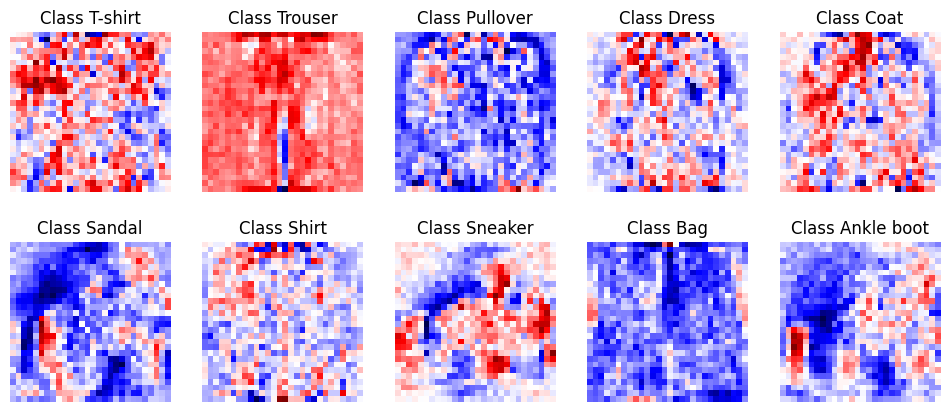

In [217]:
visualize_weights(w_hat_sgd)

Even in the heatmap visualization we can see the pullover, dress and coat as much more similar to the shape of a real class.

The Bag and Trouser classes still arnt perfect and didnt got the full shape and important features.

## Final Analsys ##
After we checked 3 different gradient decsend algorithms and saw that SGD gives us the best results we will try and compare it with PLA and see some more graphs on it.

In [28]:
def predict(X, w):
  """
  X: shape (N, d)
  w: shape (10, d)
  """
  scores = X @ w
  return np.argmax(scores, axis=1)

y_true = np.argmax(y_test, axis=1)
y_pred = predict(X_test, w_hat_sgd)

### Class-wise Sensetivity ###
we calculate TPR (True-positive rate) or Sensetivity as:


$$
\frac{TP}{(TP + FN)}
$$


This graph will show us the TPR for each class and will help us asses the classifier power.


In [29]:
def class_wise_sensitivity(y_true, y_pred, num_classes=10):
    sensitivities = np.zeros(num_classes)

    for c in trange(num_classes):
        # True positives: predicted c AND true c
        TP = np.sum((y_true == c) & (y_pred == c))

        # False negatives: true c but predicted != c
        FN = np.sum((y_true == c) & (y_pred != c))

        # Sensitivity = TP / (TP + FN)
        if TP + FN > 0:
            sensitivities[c] = TP / (TP + FN)
        else:
            sensitivities[c] = 0.0  # or np.nan if you want

    return sensitivities

print ("Calculating sensitivity per class")
sens = class_wise_sensitivity(y_true, y_pred)

Calculating sensitivity per class


  0%|          | 0/10 [00:00<?, ?it/s]

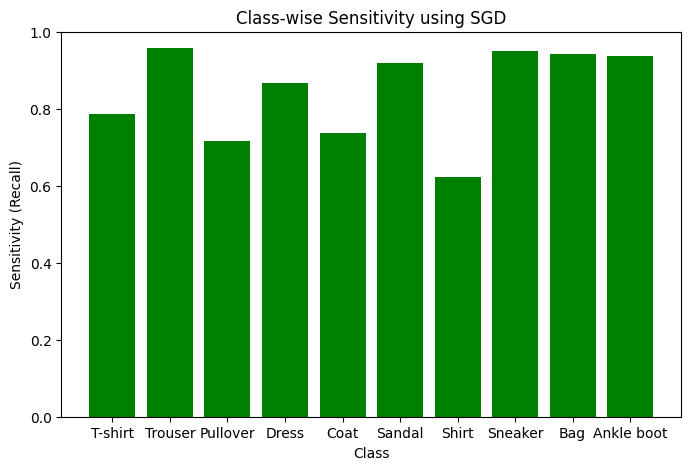

In [30]:
plt.figure(figsize=(8,5))
plt.bar(label2catagory.values(), sens, color='green')
plt.xlabel("Class")
plt.ylabel("Sensitivity (Recall)")
plt.title("Class-wise Sensitivity using SGD")
plt.ylim(0, 1)
plt.show()

It is looking like we have some classes that have much better sensetivity then others as the sensetivity for trousers, sneakers, bags, sandals and ankle boots are close to 1 and more then 0.9.

Other classes like shirt, coat ant T-shirt have much lower sensativity (0.6-0.8) and may be harder to our model to identify.

Lets now compare the sensativity of the PLA algorithm.

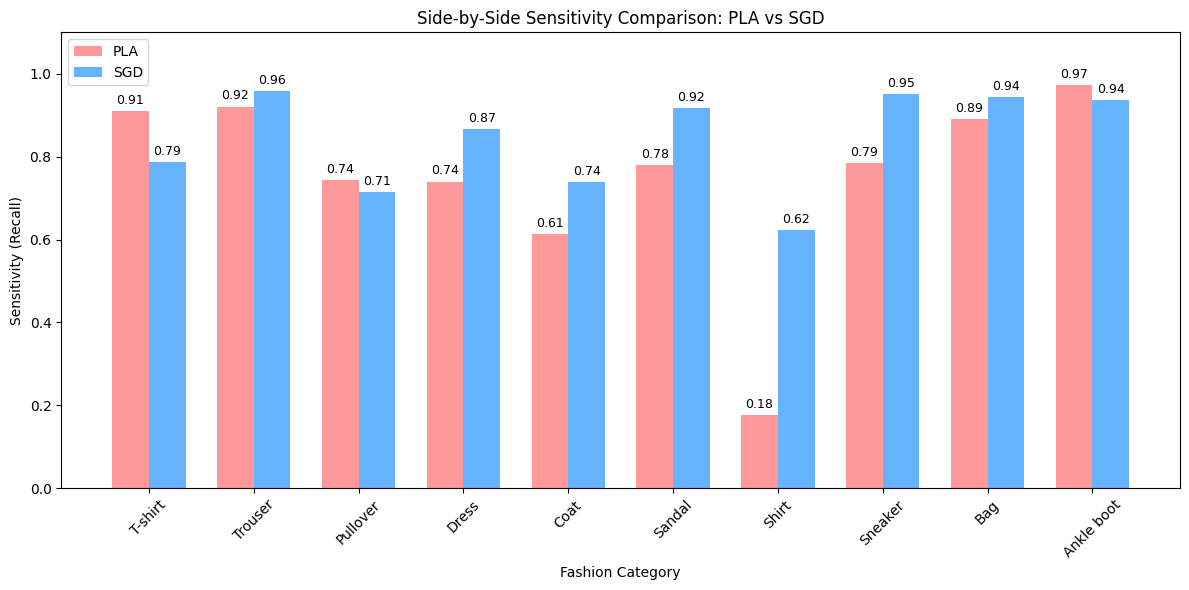

In [38]:
pla_sens = [0.91 , 0.921, 0.743, 0.74 , 0.613, 0.78 , 0.177, 0.785, 0.89 ,
       0.972]
sgd_sens = [0.787, 0.958, 0.715, 0.866, 0.738, 0.918, 0.623, 0.951, 0.943,
       0.937]

width = 0.35  # the width of the bars
x = np.arange(10)

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, pla_sens, width, label='PLA', color='#ff9999')
rects2 = ax.bar(x + width/2, sgd_sens, width, label='SGD', color='#66b3ff')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Fashion Category')
ax.set_ylabel('Sensitivity (Recall)')
ax.set_title('Side-by-Side Sensitivity Comparison: PLA vs SGD')
ax.set_xticks(x)
ax.set_xticklabels(label2catagory.values(), rotation=45)
ax.set_ylim(0, 1.1)
ax.legend()

# Add value labels on top of the bars
def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig('sensitivity_comparison.png')
plt.show()

We can see that the biggest difference between the models is that the softmax-regression that used SGD had **much better understanding of the Shirt class**. The jump from 0.18 to 0.62 TPR is massive.

The sensetivity Increase and the confidence of the model in its ability to identify the Shirt catagory probably was the reason to the minor drop in T-shirt class as the pictures of them are really similar.

Another intersting observation is the fact that in the shoes classes the softmax-regression with SGD was just better in all of the catagories: Sandals, Sneaker and Ankle boot sensativity all increased!

##### Confusion Matrix

Well look at the confusion matrix now to see

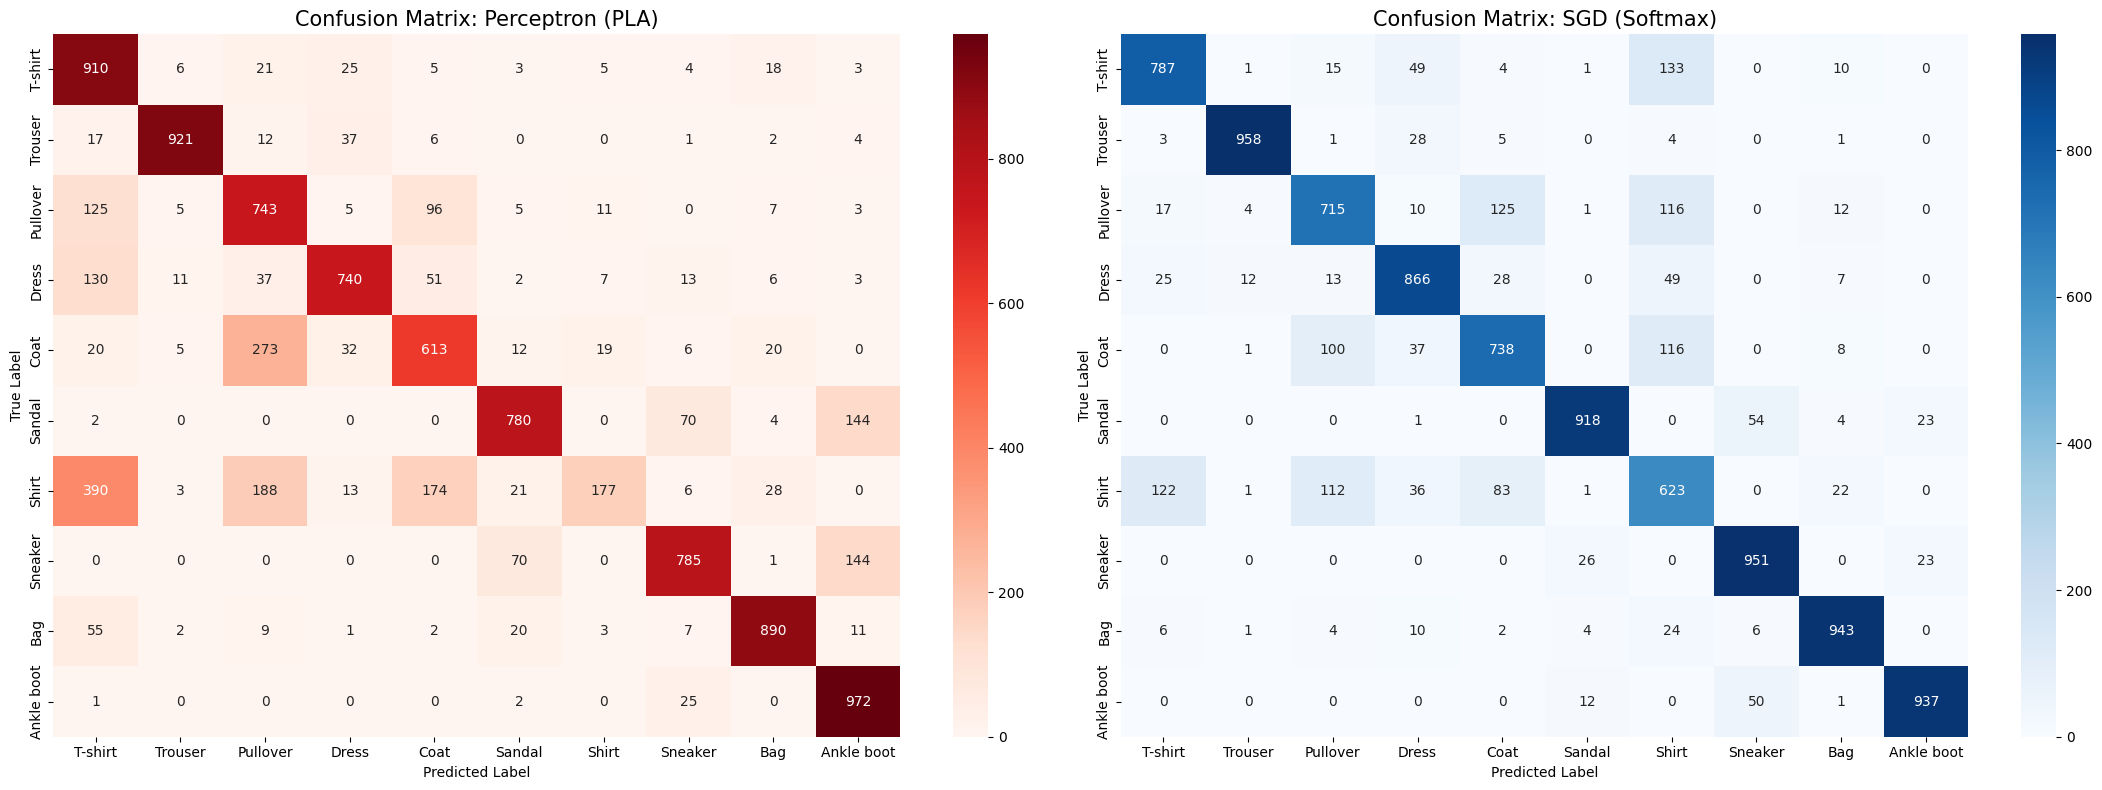

In [40]:
from sklearn.metrics import confusion_matrix

cm_pla = [[910,   6,  21,  25,   5,   3,   5,   4,  18,   3],
       [ 17, 921,  12,  37,   6,   0,   0,   1,   2,   4],
       [125,   5, 743,   5,  96,   5,  11,   0,   7,   3],
       [130,  11,  37, 740,  51,   2,   7,  13,   6,   3],
       [ 20,   5, 273,  32, 613,  12,  19,   6,  20,   0],
       [  2,   0,   0,   0,   0, 780,   0,  70,   4, 144],
       [390,   3, 188,  13, 174,  21, 177,   6,  28,   0],
       [  0,   0,   0,   0,   0,  70,   0, 785,   1, 144],
       [ 55,   2,   9,   1,   2,  20,   3,   7, 890,  11],
       [  1,   0,   0,   0,   0,   2,   0,  25,   0, 972]]

cm_sgd = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(1, 2, figsize=(22, 8))

categories = label2catagory.values()

# Plot PLA Confusion Matrix
sns.heatmap(cm_pla, annot=True, fmt='d', cmap='Reds', ax=ax[0],
            xticklabels=categories, yticklabels=categories)
ax[0].set_title('Confusion Matrix: Perceptron (PLA)', fontsize=15)
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

# Plot SGD Confusion Matrix
sns.heatmap(cm_sgd, annot=True, fmt='d', cmap='Blues', ax=ax[1],
            xticklabels=categories, yticklabels=categories)
ax[1].set_title('Confusion Matrix: SGD (Softmax)', fontsize=15)
ax[1].set_xlabel('Predicted Label')
ax[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

##### **Confusion Matrix Comparison Analsys** #####
Now we can see the diffrences in the sensativity graph clearly!
 In the PLA confusion matrix we can see it was over-confident with the T-Shirt catagory, wrongly classfieng similar looking clothing items as the Shirt catagory sufferd it the most. In our new softmax regression we can see that it reduced the number of False Positives of in the Shirt class and classified much better the Dress and Shirt classes.

**Which catagories are Easiest and Hardest to classify?**


 We saw in maman-11 that there are really tough clothing classes to classify as they have many similarities between them. we can see it in the confusion matrix and sensativity in both softmax and PLA that the Upper Body Clothing catagories (Shirt, T-Shirt, Pullover, Dress, Coat) are the toughest to classify as the Shirt and T-Shirt catagorie are the most confusing for the models.

 The Shoes catagories (Sandal, Sneaker, Ankle Boot) have similar look also but they have enogh difference from one another that the models can identify them in really high accuarcy.

 Trousers and Bags are the easiest catagories to identify, even for the human eye they look really different than the other classes and indeed they achieved the best scores in both of the models.